# Phase 2 — The Volatility Surface (and the web app)

In Phase 1 we learned to **invert** Black-Scholes: given an option's market price, solve for
the **implied volatility (IV)**. We did that for many strikes at a *single* expiry and saw the
**smile/skew** — IV is not constant across strikes.

Phase 2 adds the second dimension: **time**. When you solve IV for every strike *and* every
expiry, you get a 2D field, `IV(strike, maturity)` — the **volatility surface**. This notebook
teaches:

1. **Term structure** — how ATM vol changes with maturity (the "time" axis)
2. **The full surface** — stitching many expiries together
3. **Why we interpolate** — turning ragged market quotes into a smooth mesh you can plot
4. **The new code** — `optvol/surface.py`, `optvol/plots.py`, and the Streamlit app `app.py`

> Prerequisite: read `notebooks/01_understanding_the_project.ipynb` first. This builds directly
> on the implied-vol idea from there.

> Cells marked **LIVE DATA** need internet. Everything else runs offline.

In [7]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
import numpy as np
import matplotlib.pyplot as plt
print("Phase 2 notebook — surface concepts")

Phase 2 notebook — surface concepts


## 1. Recap in one picture: the smile (one expiry)

The smile/skew is IV plotted against strike, holding **expiry fixed**. It's a *slice* of the
surface along the strike axis. Here's a synthetic equity-style skew to anchor the idea
(OTM puts — low strikes — have higher IV because investors pay up for crash protection).

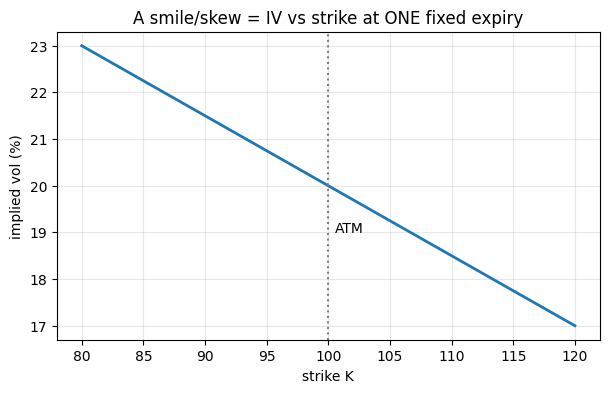

In [8]:
strikes = np.linspace(80, 120, 41)
skew_iv = 0.20 + 0.0015 * (100 - strikes)   # downward slope = equity put skew

plt.figure(figsize=(7, 4))
plt.plot(strikes, skew_iv * 100, lw=2)
plt.axvline(100, ls=":", color="gray"); plt.text(100.5, 19, "ATM")
plt.xlabel("strike K"); plt.ylabel("implied vol (%)")
plt.title("A smile/skew = IV vs strike at ONE fixed expiry")
plt.grid(alpha=0.3); plt.show()

## 2. The new axis: term structure (one moneyness, many expiries)

Now hold the **strike near spot** (at-the-money) and vary the **expiry** instead. Plotting ATM
IV against maturity gives the **term structure of volatility**.

- **Upward sloping (contango)** — near-term vol is low, longer-dated vol is higher. Typical in
  calm markets: the market assumes more *could* happen the further out you look.
- **Downward sloping (backwardation / inversion)** — near-term vol is *higher* than long-term.
  This often signals near-term stress (an earnings date, an election, a crisis) where traders
  expect a big move *soon*.

So the surface has two cross-sections that tell different stories:

| Cross-section | Axis varied | What it shows |
|---|---|---|
| **Smile / skew** | strike (at fixed expiry) | fear of large moves up/down |
| **Term structure** | expiry (at fixed ~ATM strike) | *when* the market expects volatility |

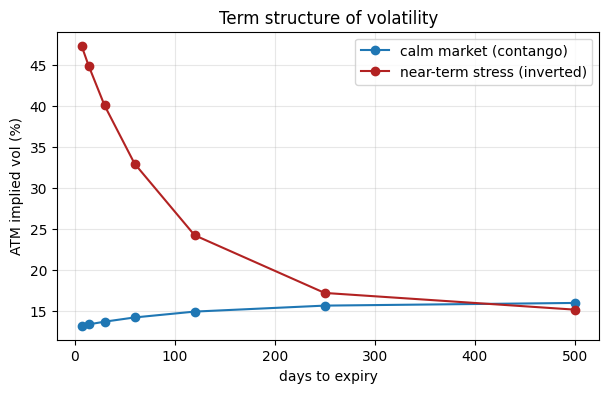

In [9]:
# Synthetic term structures: calm (contango) vs stressed (inverted).
days = np.array([7, 14, 30, 60, 120, 250, 500])
contango = 0.13 + 0.03 * (1 - np.exp(-days / 120))
inverted = 0.35 * np.exp(-days / 90) + 0.15

plt.figure(figsize=(7, 4))
plt.plot(days, contango * 100, "-o", label="calm market (contango)")
plt.plot(days, inverted * 100, "-o", color="firebrick", label="near-term stress (inverted)")
plt.xlabel("days to expiry"); plt.ylabel("ATM implied vol (%)")
plt.title("Term structure of volatility"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 3. Put them together: the surface

Stack a smile at **every** expiry and you get the full surface `IV(strike, maturity)`. Instead
of raw strike we usually use **moneyness = K / S** (1.0 = at-the-money) so different expiries —
and even different stocks — line up on a common x-axis.

Below is a synthetic surface combining a strike-skew and a term structure, just to see the
shape. (The real one from live data comes next.)

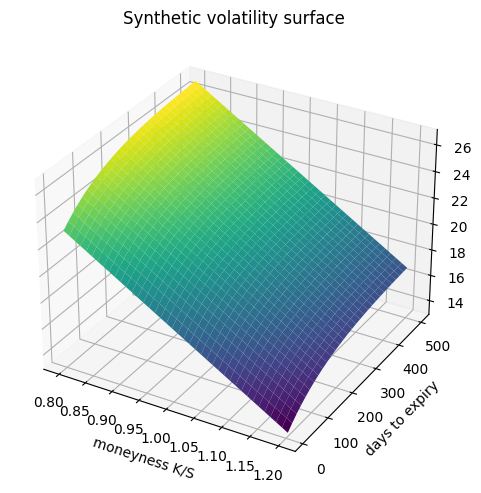

In [10]:
money = np.linspace(0.8, 1.2, 40)          # K / S
days  = np.linspace(7, 500, 30)
M, D = np.meshgrid(money, days)

# skew in the moneyness direction + rising level with maturity
iv = (0.18
      + 0.25 * (1.0 - M)                    # skew: lower strikes -> higher IV
      + 0.04 * (1 - np.exp(-D / 150)))      # term structure: rises with time

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(M, D, iv * 100, cmap="viridis")
ax.set_xlabel("moneyness K/S"); ax.set_ylabel("days to expiry"); ax.set_zlabel("IV (%)")
ax.set_title("Synthetic volatility surface")
plt.tight_layout(); plt.show()

## 4. Why interpolation is necessary

Real market quotes are **ragged**: each expiry lists a *different* set of strikes, contracts get
filtered out for bad quotes, and the points don't fall on a neat grid. You can't draw a smooth
surface through scattered, irregular points directly.

So `optvol/surface.py` does what every vol desk does: it **interpolates** the scattered
`(moneyness, maturity) -> IV` points onto a regular mesh (using `scipy.interpolate.griddata`).
Points outside the data's convex hull are left as `NaN` rather than fabricated.

The toy below shows the idea: scattered samples in, smooth grid out.

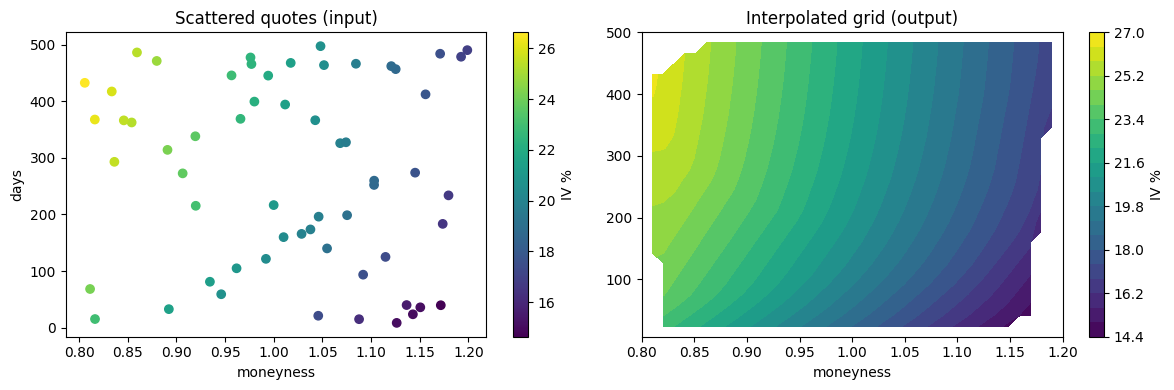

In [11]:
from scipy.interpolate import griddata

# Scattered, irregular samples (like real option quotes).
rng = np.random.default_rng(0)
pts = rng.uniform([0.8, 7], [1.2, 500], size=(60, 2))
vals = 0.18 + 0.25 * (1 - pts[:, 0]) + 0.04 * (1 - np.exp(-pts[:, 1] / 150))

# Regular target mesh.
gm, gd = np.meshgrid(np.linspace(0.8, 1.2, 40), np.linspace(7, 500, 30))
grid = griddata(pts, vals, (gm, gd), method="linear")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sc = ax[0].scatter(pts[:, 0], pts[:, 1], c=vals * 100, cmap="viridis")
ax[0].set_title("Scattered quotes (input)"); ax[0].set_xlabel("moneyness"); ax[0].set_ylabel("days")
plt.colorbar(sc, ax=ax[0], label="IV %")
im = ax[1].contourf(gm, gd, grid * 100, cmap="viridis", levels=20)
ax[1].set_title("Interpolated grid (output)"); ax[1].set_xlabel("moneyness")
plt.colorbar(im, ax=ax[1], label="IV %")
plt.tight_layout(); plt.show()

## 5. The real thing — live surface from the project code

Now we use the actual Phase 2 modules:

- `optvol.surface.load_surface(symbol)` — loads several expiries (chosen to **span** maturity,
  skipping noisy near-0-DTE ones), reuses the Phase-1 `enrich_chain` pipeline on each, and
  stacks them into one tidy DataFrame. It exposes `.smile(expiry)`, `.term_structure()`, and
  `.grid()`.
- `optvol.plots` — returns ready-made Plotly figures for the app and notebooks.

**LIVE DATA below.**

In [12]:
# LIVE DATA — requires internet.
from optvol.surface import load_surface

surf = load_surface("SPY", max_expiries=6)
print("Ticker:", surf.symbol, " spot:", round(surf.spot, 2))
print("Expiries (spanning maturity):", surf.expiries)
print("OTM points across all expiries:", len(surf.otm()))
print("\nTerm structure:")
print(surf.term_structure().to_string(index=False))

Ticker: SPY  spot: 751.9
Expiries (spanning maturity): ['2026-06-22', '2026-06-30', '2026-08-21', '2026-11-20', '2027-03-31', '2028-12-15']
OTM points across all expiries: 1173

Term structure:
    expiry        T  days   atm_iv
2026-06-22 0.016627     6 0.099136
2026-06-30 0.038545    14 0.112945
2026-08-21 0.181010    66 0.149143
2026-11-20 0.430325   157 0.165016
2027-03-31 0.789230   288 0.177809
2028-12-15 2.501558   913 0.202345


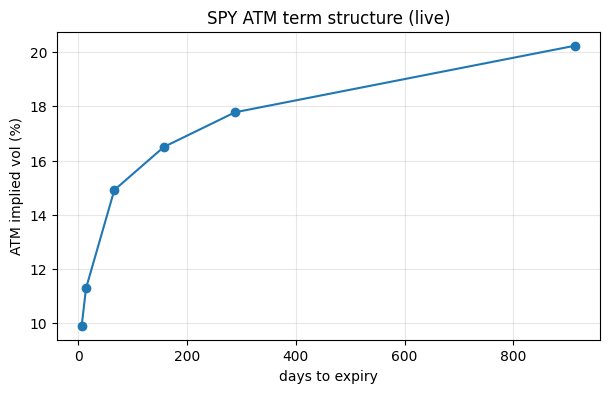

In [13]:
# Plot the REAL term structure you just computed.
ts = surf.term_structure()
plt.figure(figsize=(7, 4))
plt.plot(ts["days"], ts["atm_iv"] * 100, "-o")
plt.xlabel("days to expiry"); plt.ylabel("ATM implied vol (%)")
plt.title(f"{surf.symbol} ATM term structure (live)")
plt.grid(alpha=0.3); plt.show()

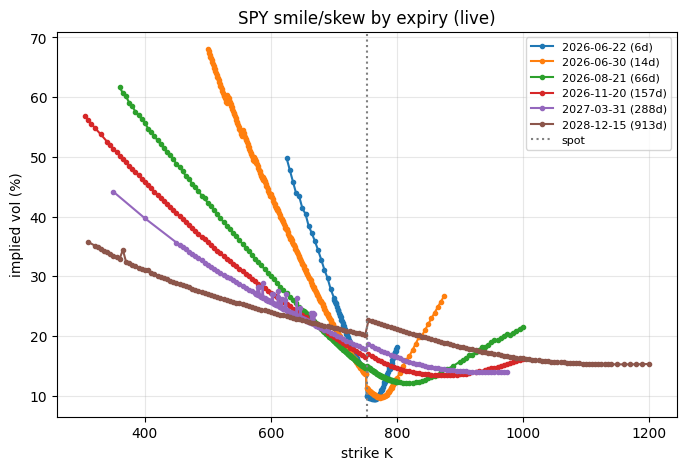

In [14]:
# Plot the REAL smile slices, one curve per expiry.
plt.figure(figsize=(8, 5))
for exp in surf.expiries:
    s = surf.smile(exp)
    if s.empty:
        continue
    plt.plot(s["strike"], s["iv_solved"] * 100, "-o", ms=3,
             label=f"{exp} ({int(s['days_to_expiry'].iloc[0])}d)")
plt.axvline(surf.spot, ls=":", color="gray", label="spot")
plt.xlabel("strike K"); plt.ylabel("implied vol (%)")
plt.title(f"{surf.symbol} smile/skew by expiry (live)")
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

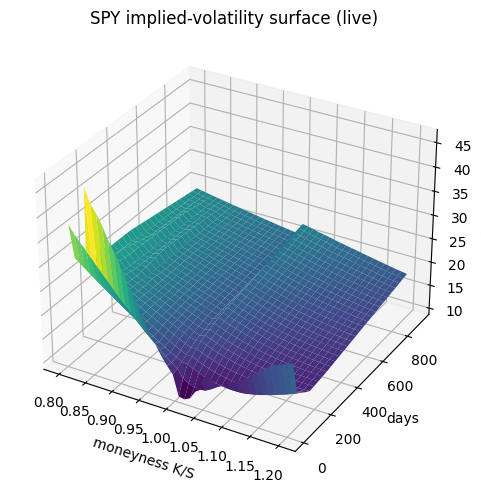

In [15]:
# The interpolated 3D grid that powers the Plotly surface in the web app.
m_axis, t_axis, iv = surf.grid()
M, D = np.meshgrid(m_axis, t_axis * 365)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(M, D, iv * 100, cmap="viridis")
ax.set_xlabel("moneyness K/S"); ax.set_ylabel("days"); ax.set_zlabel("IV (%)")
ax.set_title(f"{surf.symbol} implied-volatility surface (live)")
plt.tight_layout(); plt.show()

### The interactive Plotly versions (as used in the app)

`optvol.plots` returns Plotly figures. In Jupyter these are fully interactive (rotate, hover).

In [16]:
from optvol.plots import surface_figure, smile_figure, term_structure_figure
surface_figure(surf)   # drag to rotate; hover for values

In [17]:
smile_figure(surf)

In [18]:
term_structure_figure(surf)

## 6. The web app

`app.py` wraps all of the above in a **Streamlit** dashboard: a ticker box, the 3D surface,
smile and term-structure panels, a sortable **model-vs-market divergence** table, and a
**data-quality** report showing why noisy contracts were dropped.

Run it from a terminal (not from inside the notebook):

```bash
streamlit run app.py
```

Key engineering choices to be able to explain:

- **`@st.cache_data(ttl=300)`** — surface loads are cached for 5 minutes so re-rendering the UI
  doesn't re-hit yfinance on every interaction.
- **OTM-only surface** — same rationale as Phase 1: OTM options carry the time value, so their
  IVs are well-conditioned; deep-ITM quotes are stale and noisy.
- **Span-maturity expiry sampling** — tickers like SPY list *daily* expiries; naively taking the
  first N gives a surface only days wide, so `load_surface` samples expiries evenly across the
  available range and skips near-0-DTE.
- **Plotting kept in `optvol/plots.py`**, separate from the app, so the same figures work in
  this notebook, in tests, or in any other front-end.

## Recap — the one-paragraph version

> The **volatility surface** is implied vol as a function of both **strike** and **maturity**,
> `IV(K, T)`. Its two cross-sections each tell a story: the **smile/skew** (vary strike) shows
> fear of large moves, and the **term structure** (vary maturity) shows *when* the market expects
> volatility. Building it means solving IV for every contract across several expiries, then
> **interpolating** the ragged market quotes onto a smooth mesh. This phase turned the Phase-1
> engine into an interactive **Streamlit app** that renders the live surface, its slices, and the
> places a single-vol model diverges from the market.

### Where to go next
- Open `optvol/surface.py` and match `.smile()`, `.term_structure()`, and `.grid()` to Sections
  1–4 here.
- Run `streamlit run app.py` and explore a few tickers (try `AAPL`, `NVDA`, `TLT`).
- Phase 3 (roadmap) adds a **Monte Carlo** engine to price path-dependent options that
  Black-Scholes can't.